# Pipeline end-to-end: Preprocesado → CNN-AE → TCN → Semáforo

Este notebook orquesta todo el flujo del repo:
1) Preprocesado (como en `eda_notebook`)
2) Entrenamiento del `CNN-AE` para aprender la 'normalidad' y obtener el MSE por ventana
3) Calibrado de umbrales y visualización del semáforo a partir del MSE
4) Uso del `CNN-AE` como extractor congelado y entrenamiento de una `TCN` + cabezas multitarea para producir señales BUY/HOLD/SELL

Cada sección explica qué hace y por qué antes del código, y se basa en los módulos `load_data.py`, `cnn_ae.py` y el notebook TCN ya presente en el repo.

**Nota:** si ejecutas en Colab, descomentad las instalaciones en la siguiente celda. En local pueden no ser necesarias.

In [8]:
pip install yfinance "numpy<2.0.0" "pandas==2.2.2"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 106.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.3
    Uninstalling pandas-3.0.3:
      Successfully uninstalled pandas-3.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.71b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
pandas-ta 0.4.71b0 requires pandas>=2.3.2, but you have pandas 2.2

In [4]:
# Limpiar carpeta previa para asegurar un clonado limpio
!rm -rf TFE

# Clonar la rama específica develop_cris
!git clone -b develop_cris https://github.com/cperezg01/TFE.git

# Verificar qué se ha descargado realmente
print('\n--- Estructura del repositorio clonado (rama develop_cris) ---')
!ls -R TFE/

# Confirmar presencia de archivos .py
print('\n--- Archivos Python encontrados ---')
!find TFE -name "*.py"

Cloning into 'TFE'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 97 (delta 39), reused 51 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 2.90 MiB | 28.81 MiB/s, done.
Resolving deltas: 100% (39/39), done.

--- Estructura del repositorio clonado (rama develop_cris) ---
TFE/:
cnn_ae.py     medias_moviles.py  notebooks  tcn.py
load_data.py  metrics.py	 README.md

TFE/notebooks:
end_to_end_pipeline.ipynb

--- Archivos Python encontrados ---
TFE/cnn_ae.py
TFE/metrics.py
TFE/tcn.py
TFE/load_data.py
TFE/medias_moviles.py


In [6]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

# Añadir el directorio raíz del repositorio al path de Python
repo_path = os.path.abspath('./TFE')
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

print(f'Repo path added to sys.path: {repo_path}')

# Importar utilidades del repo con manejo de errores robusto
try:
    from load_data import DataProcessor
    from cnn_ae import ConvAutoencoder, train_autoencoder, compute_reconstruction_errors, calibrate_thresholds, classify_signals, save_model, load_model, plot_training_history, plot_semaforo as plot_semaforo_mse
    from tcn import SemaforoAgent, build_zf_sequences, forward_returns, train_supervised, run_inference, apply_trend_gate, plot_semaforo
    from metrics import compute_sharpe_ratio, compute_maximum_drawdown, evaluate_tfm_criteria
    from medias_moviles import generate_ma_signals

    # Definimos make_windows localmente ya que no está exportada en el módulo tcn.py
    def make_windows(d, ws=30):
        return np.array([d[i:i+ws] for i in range(len(d) - ws)])

    print('Imports successful! (Using local make_windows)')
except ImportError as e:
    print(f'Import failed: {e}')

Repo path added to sys.path: /content/TFE
Imports successful! (Using local make_windows)


## Preprocesado y Detección de Anomalías (CNN-AE)

En esta etapa, el pipeline realiza las siguientes operaciones clave para cada activo:

*   **Descarga y Feature Engineering**: Se obtienen los datos históricos mediante `yfinance` y se calculan indicadores técnicos (Log Returns, Volatilidad, RSI, MACD, SMA) que sirven como señales de entrada.
*   **División Temporal Estricta**: Los datos se separan en un periodo de **estabilidad** (entrenamiento) y un periodo de **test** (fuera de muestra) para evitar el sesgo de supervivencia.
*   **Normalización y Ventaneo**: Se escalan las características mediante `MinMaxScaler` (ajustado solo en train) y se transforman en ventanas temporales de 30 días (`WINDOW_SIZE`) para que el modelo capture patrones secuenciales.
*   **Entrenamiento del Autoencoder (CNN-AE)**: Se entrena una red neuronal convolucional para reconstruir los datos del periodo estable. Al finalizar, el modelo habrá aprendido la 'huella dactilar' de la normalidad del mercado.
*   **Semáforo de Anomalías (MSE)**: Se calcula el Error Cuadrático Medio (MSE) de reconstrucción. Si el error en test es significativamente mayor que en train, el semáforo cambia a Ámbar o Rojo, indicando que el mercado está en un régimen desconocido o volátil.

**¿Qué obtenemos de aquí?**
1.  **Curvas de Aprendizaje**: Gráficos de pérdida (MSE) en entrenamiento y validación para asegurar que el modelo convergió correctamente sin overfitting.
2.  **Semáforo de Anomalías**: Un gráfico temporal por cada activo donde se visualiza el error de reconstrucción frente a umbrales calibrados dinámicamente (Verde, Ámbar, Rojo), permitiendo identificar visualmente periodos de alta incertidumbre o cambios de régimen antes de analizar las señales de trading.

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


ANALIZANDO: IBEX 35 (^IBEX)
Descargando datos para ^IBEX...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Entrenando en: cuda


  Epoch  10/50  |  train=0.000845  val=0.000266
  Epoch  20/50  |  train=0.000582  val=0.000214
  Epoch  30/50  |  train=0.000632  val=0.000177
  Epoch  40/50  |  train=0.000641  val=0.000210
  Epoch  50/50  |  train=0.000507  val=0.000111
Umbrales calibrados — Verde<0.000276  Ámbar<0.000437


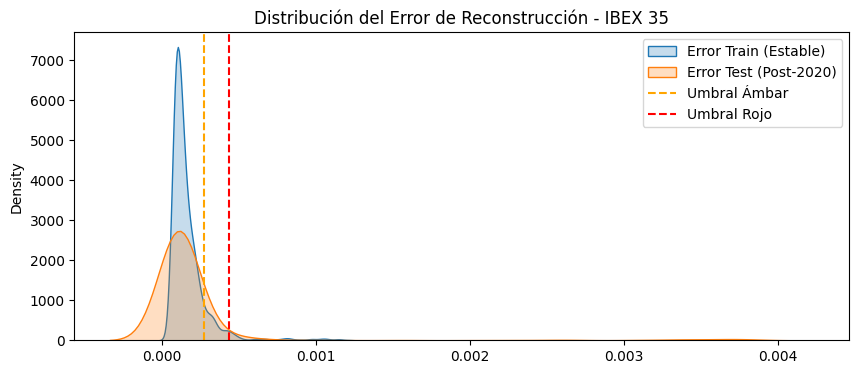

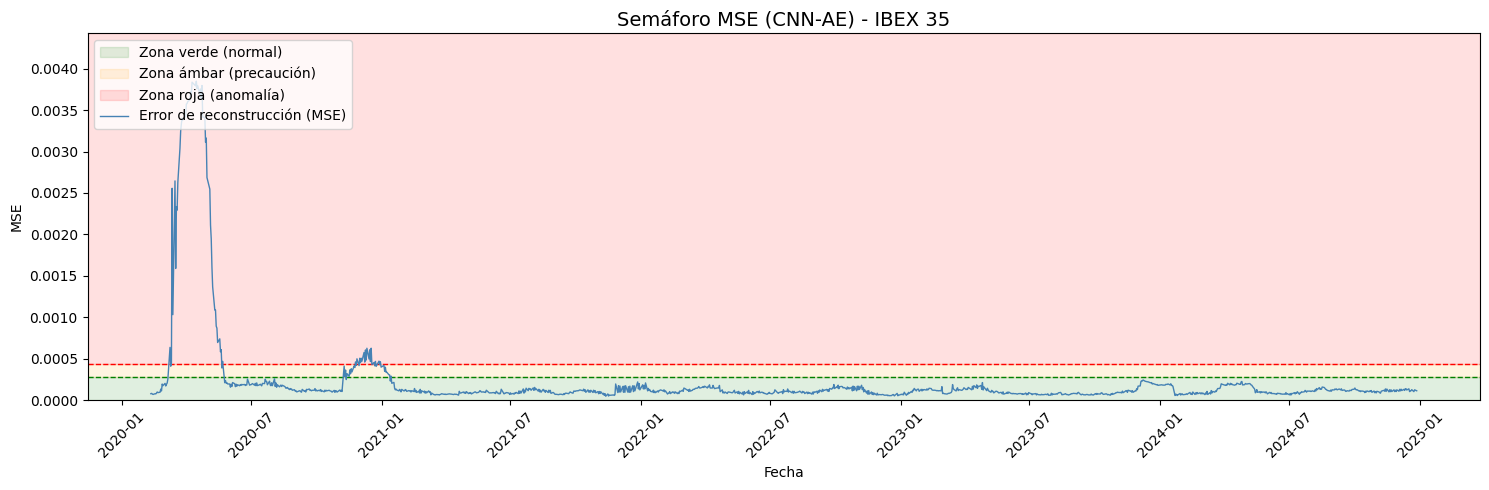

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


ANALIZANDO: S&P 500 (^GSPC)
Descargando datos para ^GSPC...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Entrenando en: cuda


  Epoch  10/50  |  train=0.000588  val=0.003924
  Epoch  20/50  |  train=0.000446  val=0.002546
  Epoch  30/50  |  train=0.000395  val=0.002865
  Epoch  40/50  |  train=0.000302  val=0.001540
  Epoch  50/50  |  train=0.000325  val=0.001324
Umbrales calibrados — Verde<0.000499  Ámbar<0.001678


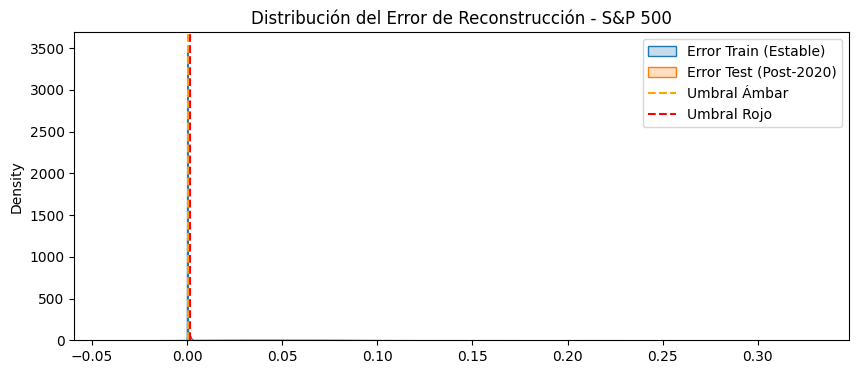

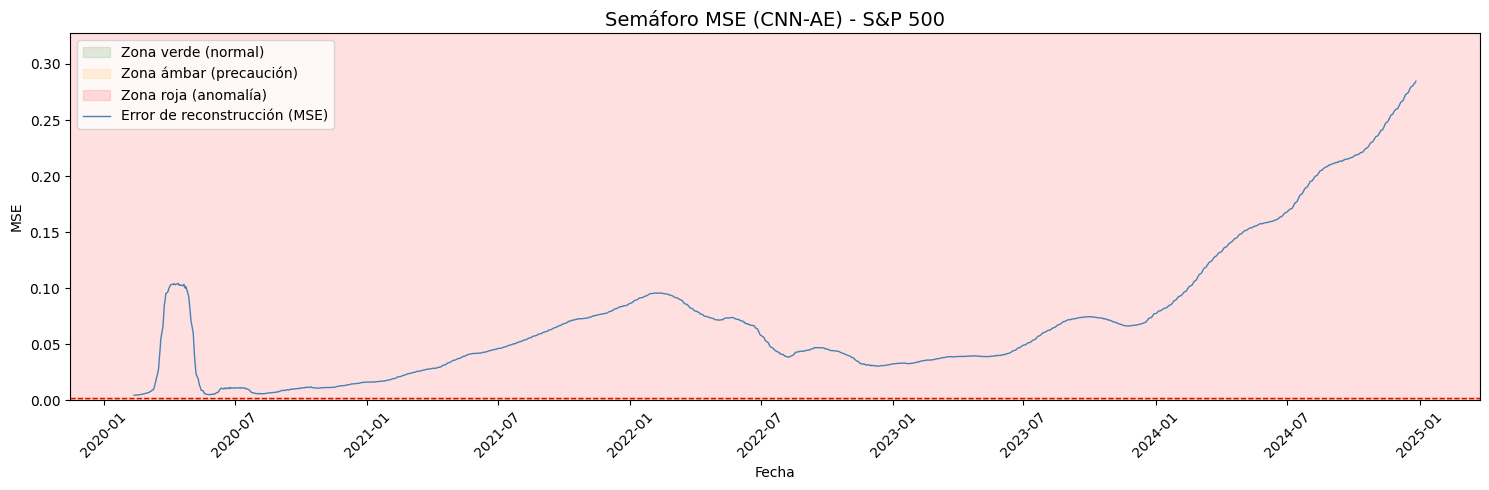

/content/TFE/load_data.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
[*********************100%***********************]  1 of 1 completed


ANALIZANDO: Oro (GC=F)
Descargando datos para GC=F...
Características añadidas. Columnas actuales: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']
Entrenando en: cuda


  Epoch  10/50  |  train=0.000806  val=0.000312
  Epoch  20/50  |  train=0.000714  val=0.000330
  Epoch  30/50  |  train=0.000597  val=0.000234
  Epoch  40/50  |  train=0.000486  val=0.000186
  Epoch  50/50  |  train=0.000449  val=0.000285
Umbrales calibrados — Verde<0.000420  Ámbar<0.000651


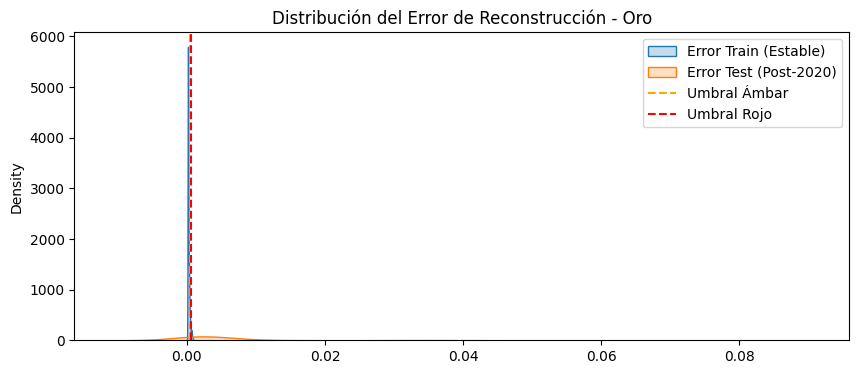

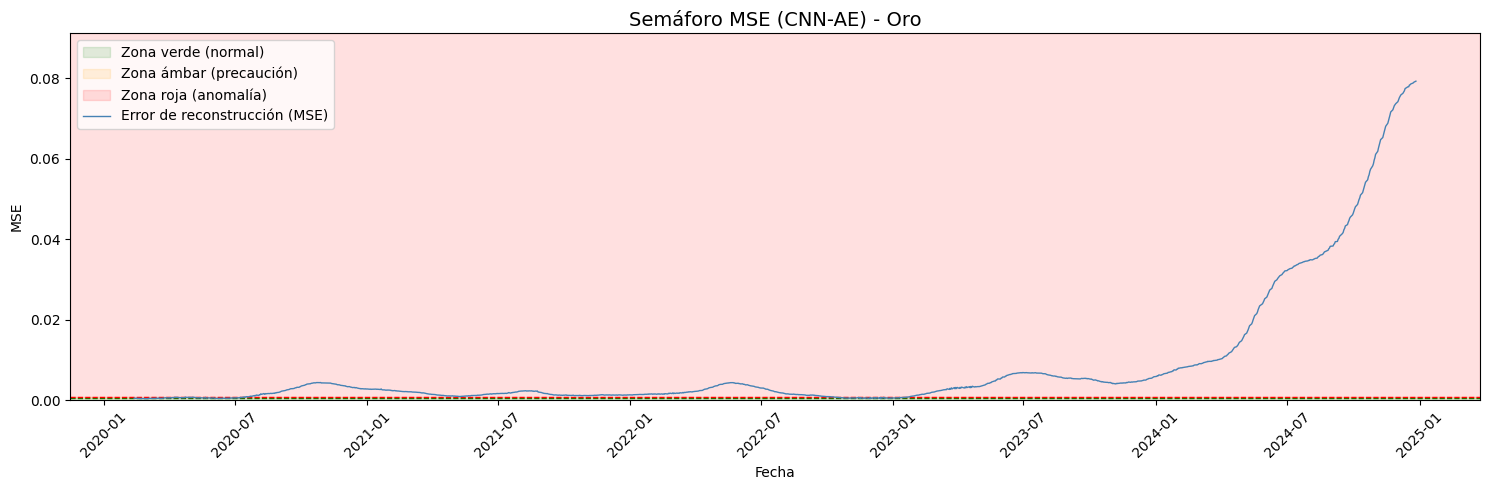

In [7]:
import seaborn as sns

# Parámetros
TICKER = ['^IBEX', '^GSPC', 'GC=F']
START_DATE = '2000-01-01'
END_DATE = '2024-12-31'
STABILITY_END = '2019-12-31'
WINDOW_SIZE = 30
FEATURE_COLS = ['Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'SMA_50']

AE_EPOCHS = 50

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assets = {'^IBEX': 'IBEX 35', '^GSPC': 'S&P 500', 'GC=F': 'Oro'}

datos_procesados_cache = {}

for ticker_symbol in TICKER:
    name = assets.get(ticker_symbol, ticker_symbol)
    print(f'\n' + '='*50)
    print(f'ANALIZANDO: {name} ({ticker_symbol})')
    print('='*50)

    proc = DataProcessor(ticker=ticker_symbol, start_date=START_DATE, end_date=END_DATE)
    proc.download_data()
    proc.add_features()
    d_df = proc.data.dropna(subset=FEATURE_COLS)

    datos_procesados_cache[ticker_symbol] = {
        'processor': proc,
        'dataframe': d_df
    }

    tr_df, ts_df = d_df[:STABILITY_END], d_df[STABILITY_END:]
    scl = MinMaxScaler()
    tr_sc = scl.fit_transform(tr_df[FEATURE_COLS])
    ts_sc = scl.transform(ts_df[FEATURE_COLS])

    xtr = make_windows(tr_sc, WINDOW_SIZE)
    xts = make_windows(ts_sc, WINDOW_SIZE)

    ae = ConvAutoencoder(n_features=len(FEATURE_COLS), seq_len=WINDOW_SIZE).to(DEVICE)
    train_autoencoder(ae, xtr, epochs=AE_EPOCHS, batch_size=64, device=DEVICE)

    tr_errs = compute_reconstruction_errors(ae, xtr, batch_size=256, device=DEVICE)
    ts_errs = compute_reconstruction_errors(ae, xts, batch_size=256, device=DEVICE)
    thresh = calibrate_thresholds(tr_errs, p_amber=90, p_red=97)

    # Diagnóstico visual de la distribución del error
    plt.figure(figsize=(10, 4))
    sns.kdeplot(tr_errs, label='Error Train (Estable)', fill=True)
    sns.kdeplot(ts_errs, label='Error Test (Post-2020)', fill=True)
    plt.axvline(thresh['green_max'], color='orange', linestyle='--', label='Umbral Ámbar')
    plt.axvline(thresh['amber_max'], color='red', linestyle='--', label='Umbral Rojo')
    plt.title(f'Distribución del Error de Reconstrucción - {name}')
    plt.legend()
    plt.show()

    t_dates_mse = ts_df.index[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(xts)]

    plot_semaforo_mse(t_dates_mse.values, ts_errs, thresh, title=f'Semáforo MSE (CNN-AE) - {name}')

## TCN: usar CNN-AE como extractor frozen y entrenar agente multitarea

En esta sección:

1.  **Extracción de Características Latentes:** Se utiliza el *encoder* del `CNN-AE` (entrenado previamente y ahora "congelado") para generar representaciones latentes `z` (vectores que encapsulan la "normalidad" de los datos) para cada ventana temporal de datos.
2.  **Ingesta de Features Auxiliares:** Se incorporan features adicionales como retornos históricos y posiciones relativas a medias móviles, que complementan los vectores `z` del autoencoder.
3.  **Construcción de Secuencias para la TCN:** Se construyen secuencias temporales (`TCN_SEQ_LEN`) de estos vectores `z` combinados con las features auxiliares. Esto permite a la TCN capturar patrones complejos a lo largo del tiempo.
4.  **Entrenamiento del Agente TCN:** Estas secuencias se utilizan para entrenar un modelo de Red Convolucional Temporal (TCN). La TCN está diseñada con dos "cabezas" de salida:
    *   **Clasificación:** Para predecir una de tres posibles acciones: BUY (comprar), HOLD (mantener) o SELL (vender).
    *   **Regresión:** Para predecir el retorno esperado del activo en un horizonte futuro.

**¿Qué obtenemos de aquí?**

*   Un agente (`SemaforoAgent`) entrenado que, a partir de la historia reciente del mercado (en forma de latentes `z` y features auxiliares), es capaz de emitir señales de trading y estimar retornos futuros.

### Evaluación del Entrenamiento: Pérdida vs Accuracy
Visualizamos la evolución del Accuracy para verificar que el aprendizaje es estable y no hay overfitting excesivo.

In [8]:
import torch
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os
import torch.nn.functional as F
import types

# Diccionarios para almacenar todo de forma unificada
trained_agents = {}

def get_latent_flat_patched(self, x):
    # Ajuste de dimensiones si es necesario (BS, Seq, Feat) -> (BS, Feat, Seq)
    if x.shape[1] == WINDOW_SIZE:
        x = x.permute(0, 2, 1)
    z = self.encoder(x)
    return torch.flatten(z, start_dim=1)

for ticker_symbol in TICKER:
    name = assets.get(ticker_symbol, ticker_symbol)
    print(f"\n{'='*50}")
    print(f"PROCESANDO ACTIVO (Pipeline Unificado): {name} ({ticker_symbol})")
    print(f"{'='*50}")

    # 1. Carga y Procesado de datos
    if ticker_symbol in datos_procesados_cache:
        proc = datos_procesados_cache[ticker_symbol]['processor']
        # Usamos .copy() para no mutar el dataframe original de la caché
        df_full = datos_procesados_cache[ticker_symbol]['dataframe'].copy()
    else:
        # Failsafe por si corres esta celda de forma aislada
        print(f"Advertencia: {ticker_symbol} no encontrado en caché. Descargando de emergencia...")
        proc = DataProcessor(ticker=ticker_symbol, start_date=START_DATE, end_date=END_DATE)
        proc.download_data()
        proc.add_features()
        df_full = proc.data.dropna(subset=FEATURE_COLS).copy()

    # División temporal
    train_df = df_full[:STABILITY_END]
    test_df = df_full[STABILITY_END:]

    # Escalamiento y ventanas para reutilizar el Autoencoder de la celda de arriba
    X_train_ae = make_windows(scl.transform(train_df[FEATURE_COLS]), WINDOW_SIZE)
    X_test_ae = make_windows(scl.transform(test_df[FEATURE_COLS]), WINDOW_SIZE)

    # 2. Recuperar el Autoencoder ya entrenado en la celda de arriba
    curr_ae = ae
    curr_ae.eval() # Lo ponemos en modo evaluación (congelado)

    # Le volvemos a dar al objeto el método que le falta antes de pasarlo a la TCN
    curr_ae.get_latent_flat = types.MethodType(get_latent_flat_patched, curr_ae)

    # 3. Preparación de Features adicionales para TCN
    df_full['SMA_200'] = df_full['Close'].rolling(200).mean()
    feat_cols_tcn = pd.DataFrame(index=df_full.index)
    feat_cols_tcn['ret_5']     = np.log(df_full['Close'] / df_full['Close'].shift(5))
    feat_cols_tcn['ret_20']    = np.log(df_full['Close'] / df_full['Close'].shift(20))
    feat_cols_tcn['px_sma50']  = df_full['Close'] / df_full['SMA_50']  - 1.0
    feat_cols_tcn['px_sma200'] = df_full['Close'] / df_full['SMA_200'] - 1.0
    feat_cols_tcn['rsi']       = df_full['RSI_14'] / 100.0
    feat_cols_tcn['vol']       = df_full['Volatilidad']
    feat_cols_tcn = feat_cols_tcn.fillna(0.0)

    feat_train = feat_cols_tcn.loc[train_df.index]
    f_m, f_s = feat_train.mean(), feat_train.std() + 1e-8
    feat_train_sc = ((feat_train - f_m) / f_s).values.astype(np.float32)
    fw_train = feat_train_sc[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(X_train_ae)]

    # 4. Generación de secuencias Z+F para la TCN
    TCN_SEQ_LEN = 10
    z_train = build_zf_sequences(curr_ae, X_train_ae, fw_train, TCN_SEQ_LEN, DEVICE)

    # Alineación de retornos
    DEC_OFFSET = WINDOW_SIZE + TCN_SEQ_LEN - 2
    close_train = df_full['Close'].loc[train_df.index]
    fwd_train = forward_returns(close_train, DEC_OFFSET, len(z_train), horizon=8)
    r1_train = forward_returns(close_train, DEC_OFFSET, len(z_train), horizon=1)

    minlen = min(len(z_train), len(fwd_train), len(r1_train))
    z_train, fwd_train, r1_train = z_train[:minlen], fwd_train[:minlen], r1_train[:minlen]

    # 5. Entrenamiento del Agente TCN
    print(f"Entrenando Agente TCN para {name}...")
    curr_agent = SemaforoAgent(cnn_ae=curr_ae, z_dim=z_train.shape[2], tcn_channels=[32, 16], tcn_kernel=3, dropout=0.3, context_dim=64).to(DEVICE)

    history_tuple = train_supervised(curr_agent, z_train, fwd_train, r1_train, epochs=300, lr=3e-4, device=DEVICE)
    history_acc = history_tuple[0]

    # 6. Guardar los resultados en el diccionario (Reutilizando los umbrales 'thresh' y errores 'ts_errs' calculados en la celda 1)
    # ---> MODIFICADO: 'thresh' y 'ts_errs' se leen directamente de la celda de arriba sin volver a calcularse
    trained_agents[ticker_symbol] = {
        'agent': curr_agent,
        'ae': curr_ae,
        'scaler_ae': scl,
        'feat_mean': f_m,
        'feat_std': f_s,
        'history': history_acc,
        'thresholds': thresh,
        'test_mse_errors': ts_errs,
        'X_test_ae': X_test_ae # Store X_test_ae for this ticker
    }

print("\n¡Entrenamiento de la TCN completado usando el Autoencoder previo!")


PROCESANDO ACTIVO (Pipeline Unificado): IBEX 35 (^IBEX)
Entrenando Agente TCN para IBEX 35...
  Ep  20/300 | val_loss=0.7856 | val_acc=0.507
  Ep  40/300 | val_loss=0.7748 | val_acc=0.529
  Ep  60/300 | val_loss=0.8393 | val_acc=0.521
  Ep  80/300 | val_loss=0.8041 | val_acc=0.488
  Ep 100/300 | val_loss=0.8498 | val_acc=0.496
  Ep 120/300 | val_loss=0.8750 | val_acc=0.492
  Ep 140/300 | val_loss=0.9876 | val_acc=0.523
  Ep 160/300 | val_loss=0.9015 | val_acc=0.523
  Ep 180/300 | val_loss=0.8409 | val_acc=0.471
  Ep 200/300 | val_loss=1.0148 | val_acc=0.470
  Ep 220/300 | val_loss=0.9875 | val_acc=0.503
  Ep 240/300 | val_loss=1.1577 | val_acc=0.511
  Ep 260/300 | val_loss=0.9983 | val_acc=0.501
  Ep 280/300 | val_loss=0.8821 | val_acc=0.514
  Ep 300/300 | val_loss=1.4063 | val_acc=0.513
  Checkpoint: época 25 | val_loss=0.7626 | val_acc=0.565

PROCESANDO ACTIVO (Pipeline Unificado): S&P 500 (^GSPC)
Entrenando Agente TCN para S&P 500...
  Ep  20/300 | val_loss=0.7840 | val_acc=0.529
 

### Inferencia y Semáforo Final
Pasa los datos de test por el modelo final, aplica los filtros oficiales (COVERAGE + Trend Gate) y genera el gráfico de semáforo con los puntos de compra/venta en el tiempo.


>>> Ejecutando Inferencia Oficial: IBEX 35 (^IBEX) <<<


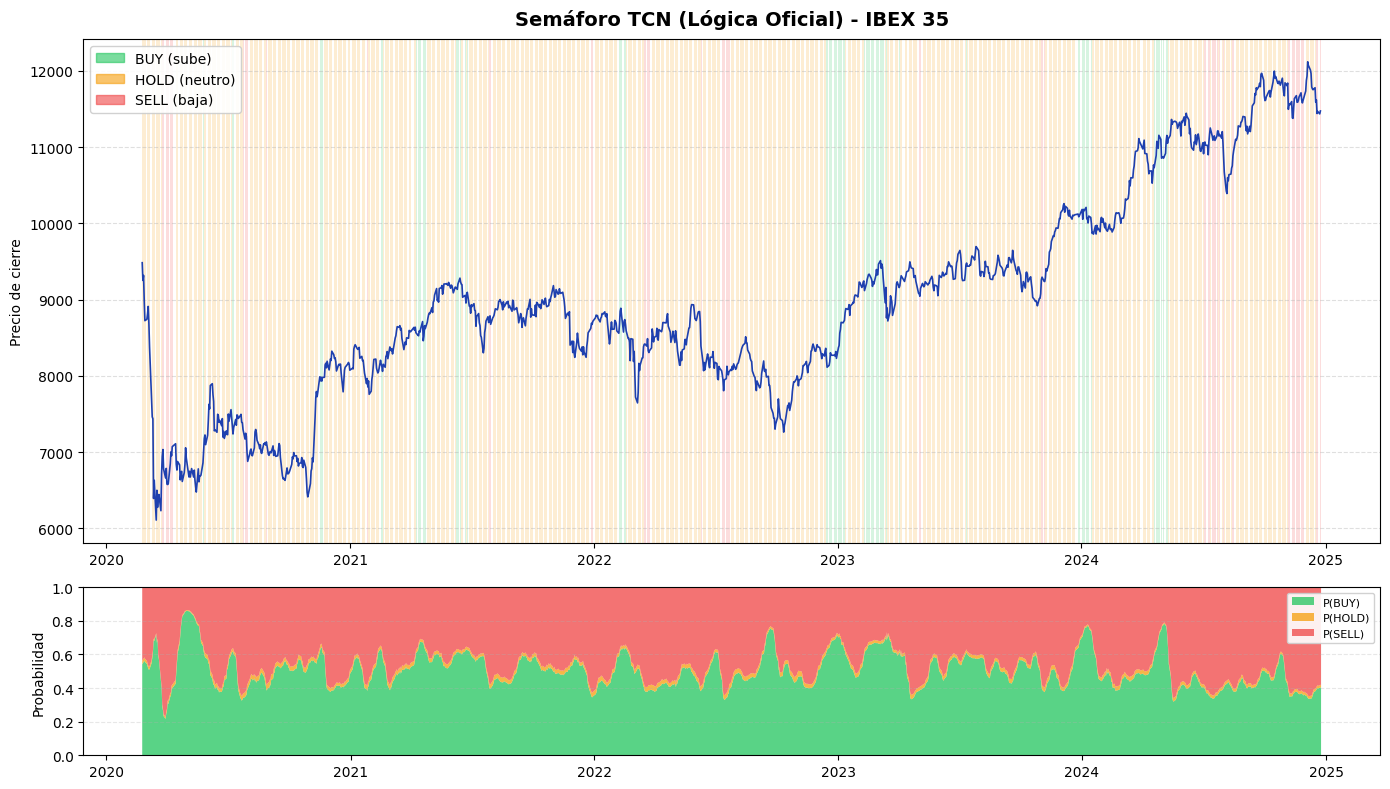

Gráfico guardado en semaforo_ibex.png
Distribución de señales final para IBEX 35:
label
HOLD    1028
BUY      118
SELL      95
Name: count, dtype: int64


>>> Ejecutando Inferencia Oficial: S&P 500 (^GSPC) <<<


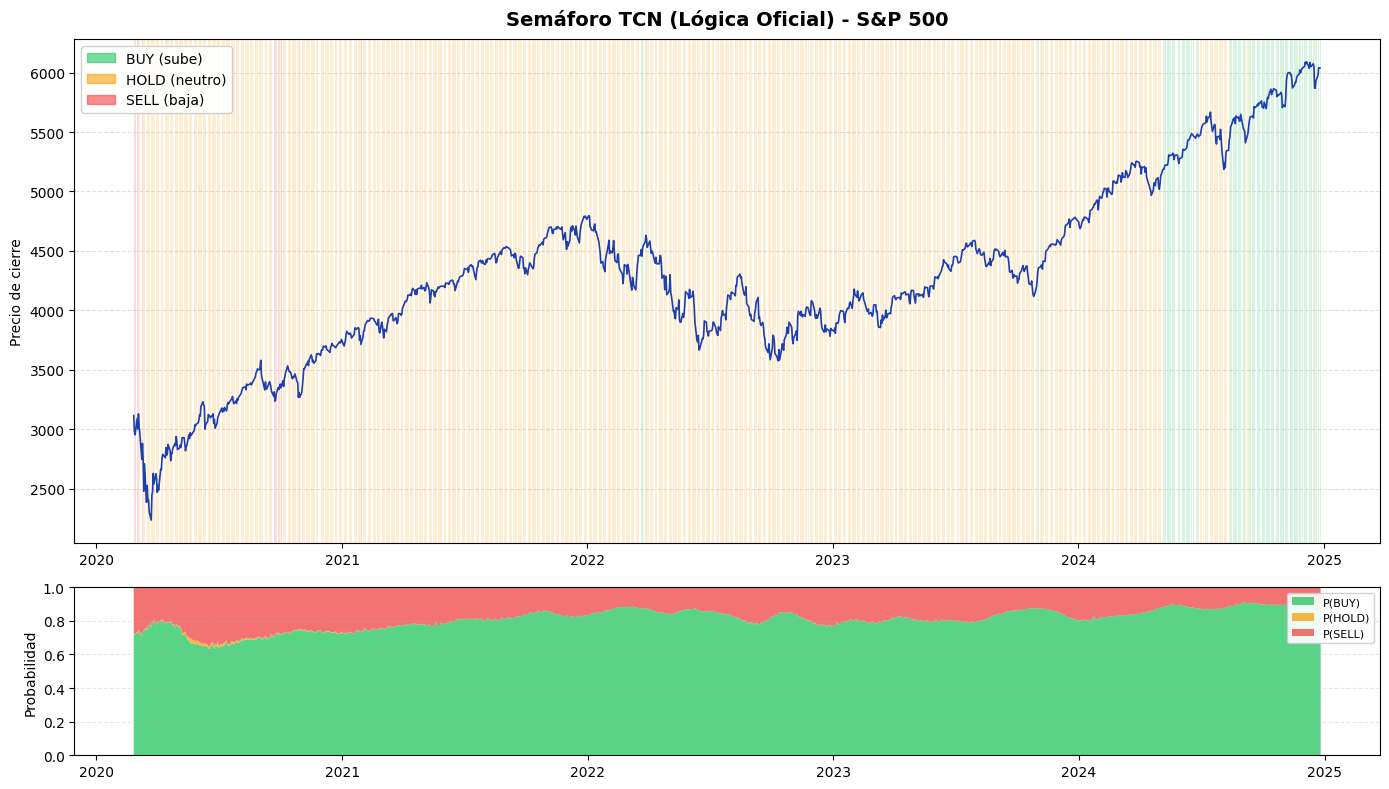

Gráfico guardado en semaforo_ibex.png
Distribución de señales final para S&P 500:
label
HOLD    1065
BUY      132
SELL      21
Name: count, dtype: int64


>>> Ejecutando Inferencia Oficial: Oro (GC=F) <<<


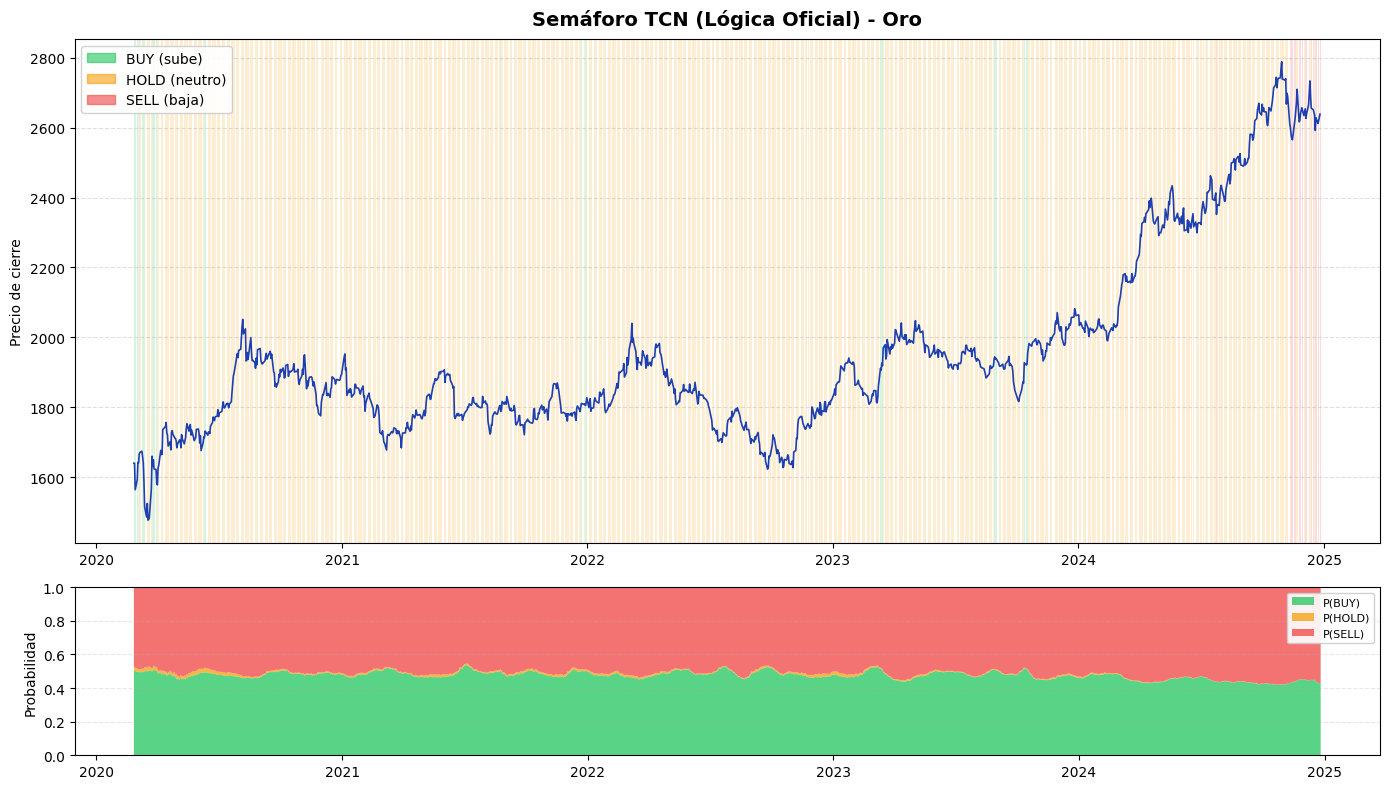

Gráfico guardado en semaforo_ibex.png
Distribución de señales final para Oro:
label
HOLD    1159
BUY       33
SELL      26
Name: count, dtype: int64



In [11]:
import builtins
import numpy as np
import pandas as pd

# --- Inferencia Unificada con Lógica Oficial del Repositorio ---
results = {}
SEMAFORO_COLORS = {0: ("#f59e0b", "HOLD"), 1: ("#22c55e", "BUY"), 2: ("#ef4444", "SELL")}
builtins.SEMAFORO_COLORS = SEMAFORO_COLORS

# Definimos el parámetro global de cobertura
COVERAGE = 0.30

for ticker_symbol, asset_info in trained_agents.items():
    name = assets.get(ticker_symbol, ticker_symbol)
    print(f"\n>>> Ejecutando Inferencia Oficial: {name} ({ticker_symbol}) <<<")

    agent = asset_info['agent']
    ae_model = asset_info['ae']
    scl_ae = asset_info['scaler_ae']
    f_m, f_s = asset_info['feat_mean'], asset_info['feat_std']
    # Nota: ts_mse está disponible pero el gate actual no lo procesa aún
    ts_mse = asset_info['test_mse_errors']
    current_X_test_ae = asset_info['X_test_ae'] # Retrieve X_test_ae for this ticker

    # 1. Preparación de datos
    if ticker_symbol in datos_procesados_cache:
        proc = datos_procesados_cache[ticker_symbol]['processor']
        df_feat = datos_procesados_cache[ticker_symbol]['dataframe'].copy()
    else:
        # Failsafe por si corres esta celda de forma aislada
        print(f"Advertencia: {ticker_symbol} no encontrado en caché. Descargando de emergencia...")
        proc = DataProcessor(ticker=ticker_symbol, start_date=START_DATE, end_date=END_DATE)
        proc.download_data()
        proc.add_features()
        df_feat = proc.data.dropna(subset=FEATURE_COLS).copy()

    # Extraemos la porción de test
    ts_df = df_feat[STABILITY_END:]

    df_feat = proc.data.copy()
    df_feat['SMA_200'] = df_feat['Close'].rolling(200).mean()
    feat_ext = pd.DataFrame(index=df_feat.index)
    feat_ext['ret_5']     = np.log(df_feat['Close'] / df_feat['Close'].shift(5))
    feat_ext['ret_20']    = np.log(df_feat['Close'] / df_feat['Close'].shift(20))
    feat_ext['px_sma50']  = df_feat['Close'] / df_feat['SMA_50']  - 1.0
    feat_ext['px_sma200'] = df_feat['Close'] / df_feat['SMA_200'] - 1.0
    feat_ext['rsi']       = df_feat['RSI_14'] / 100.0
    feat_ext['vol']       = df_feat['Volatilidad']
    feat_ext = feat_ext.fillna(0.0)

    feat_test_sc = ((feat_ext.loc[ts_df.index] - f_m) / f_s).values.astype(np.float32)
    fw_ts = feat_test_sc[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(current_X_test_ae)]

    # 2. Generación de secuencias Z+F
    z_ts_asset = build_zf_sequences(ae_model, current_X_test_ae, fw_ts, TCN_SEQ_LEN, DEVICE)

    # 3. Alineación temporal
    dec_offset = WINDOW_SIZE + TCN_SEQ_LEN - 2
    t_dates = ts_df.index[dec_offset : dec_offset + len(z_ts_asset)]

    signals_raw = run_inference(agent, z_ts_asset, t_dates, DEVICE, coverage=COVERAGE)

    # (fast=50, dd_look=20, dd_thr=-0.08)
    signals_f = apply_trend_gate(
        signals_raw,
        df_feat,
        fast=50,
        dd_look=20,
        dd_thr=-0.08
    )

    close_test_aligned = df_feat['Close'].loc[t_dates]
    results[ticker_symbol] = (signals_f, close_test_aligned)

    # Visualización actualizada con la serie alineada
    plot_semaforo(signals_f, close_test_aligned, title=f'Semáforo TCN (Lógica Oficial) - {name}')
    print(f"Distribución de señales final para {name}:\n{signals_f['label'].value_counts()}\n")

### Evaluación Estadística

Calcula el Accuracy, Precision, F1-Score, Recall y te dibuja la Matriz de Confusión comparando las señales definitivas del semáforo contra el movimiento real del precio al día siguiente.

       EVALUACIÓN ESTADÍSTICA DEL MODELO (MÉTRICAS DE CLASIFICACIÓN)   

--- RENDIMIENTO CLASIFICACIÓN PARA IBEX 35 (^IBEX) ---
Accuracy Global: 7.37%
Precision (Macro): 0.2864
Recall (Macro): 0.0482
F1-Score (Macro): 0.0825

Reporte Detallado por Clase (IBEX 35):
              precision    recall  f1-score   support

        HOLD       0.00      0.00      0.00         0
         BUY       0.49      0.09      0.15       669
        SELL       0.37      0.06      0.10       552

    accuracy                           0.07      1221
   macro avg       0.29      0.05      0.08      1221
weighted avg       0.44      0.07      0.13      1221



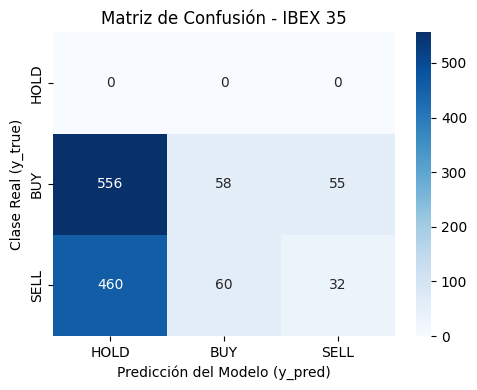



--- RENDIMIENTO CLASIFICACIÓN PARA S&P 500 (^GSPC) ---
Accuracy Global: 9.52%
Precision (Macro): 0.4628
Recall (Macro): 0.0509
F1-Score (Macro): 0.0907

Reporte Detallado por Clase (S&P 500):
              precision    recall  f1-score   support

        HOLD       0.00      0.00      0.00         0
         BUY       0.91      0.13      0.22       828
        SELL       0.48      0.03      0.05       370

    accuracy                           0.10      1198
   macro avg       0.46      0.05      0.09      1198
weighted avg       0.78      0.10      0.17      1198



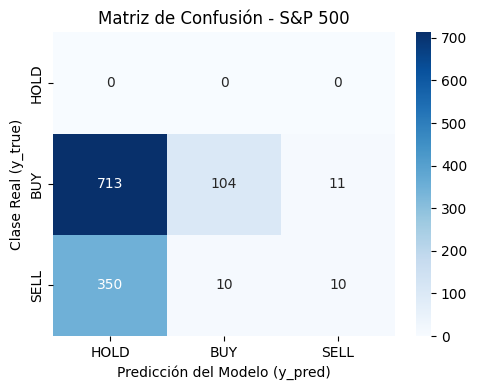



--- RENDIMIENTO CLASIFICACIÓN PARA Oro (GC=F) ---
Accuracy Global: 2.17%
Precision (Macro): 0.2730
Recall (Macro): 0.3455
F1-Score (Macro): 0.0238

Reporte Detallado por Clase (Oro):
              precision    recall  f1-score   support

        HOLD       0.00      1.00      0.00         1
         BUY       0.73      0.03      0.07       696
        SELL       0.09      0.00      0.00       501

    accuracy                           0.02      1198
   macro avg       0.27      0.35      0.02      1198
weighted avg       0.46      0.02      0.04      1198



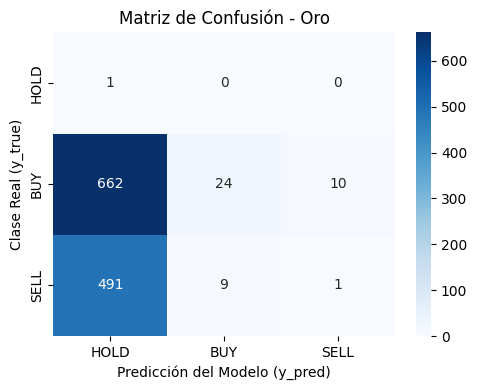

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

print("======================================================================")
print("       EVALUACIÓN ESTADÍSTICA DEL MODELO (MÉTRICAS DE CLASIFICACIÓN)   ")
print("======================================================================\n")

for ticker_symbol in trained_agents.keys():
    name = assets.get(ticker_symbol, ticker_symbol)

    if ticker_symbol not in results:
        continue

    # 1. Recuperar las señales oficiales filtradas y las fechas alineadas
    signals_f, close_test = results[ticker_symbol]
    t_dates = signals_f.index

    # 2. CORRECCIÓN: Re-calcular las etiquetas reales (y_true) utilizando el horizonte de 20 días (HORIZON)
    # y los retornos logarítmicos futuros acumulados coherentes con la memoria y tcn.py
    r20_test = forward_returns(close_test, 0, len(t_dates), horizon=20)

    y_true = np.zeros_like(r20_test, dtype=int)
    y_true[r20_test > 0.000] = 1   # BUY
    y_true[r20_test < -0.000] = 2  # SELL
    # El resto se queda en 0 (HOLD)

    # 3. Mapear las predicciones del texto ('HOLD', 'BUY', 'SELL') a números (0, 1, 2)
    mapeo_clases = {'HOLD': 0, 'BUY': 1, 'SELL': 2}
    y_pred = signals_f['label'].map(mapeo_clases).values

    # Buscamos la longitud más corta entre ambos para evitar el ValueError
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]

    # 4. Calcular métricas globales
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(f"--- RENDIMIENTO CLASIFICACIÓN PARA {name} ({ticker_symbol}) ---")
    print(f"Accuracy Global: {acc*100:.2f}%")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}")

    # 5. Imprimir el reporte detallado por cada clase
    print(f"\nReporte Detallado por Clase ({name}):")
    print(classification_report(y_true, y_pred, target_names=['HOLD', 'BUY', 'SELL'], labels=[0, 1, 2], zero_division=0))

    # 6. Calcular y graficar la Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['HOLD', 'BUY', 'SELL'],
                yticklabels=['HOLD', 'BUY', 'SELL'])
    plt.title(f'Matriz de Confusión - {name}')
    plt.ylabel('Clase Real (y_true)')
    plt.xlabel('Predicción del Modelo (y_pred)')
    plt.tight_layout()
    plt.show()
    print("\n" + "="*70 + "\n")

### Backtesting Financiero

Mide el rendimiento monetario, el Ratio de Sharpe y el Máximo Drawdown de la estrategia para validar si cumple los objetivos económicos de tu tesis frente a los benchmarks.

In [13]:
# Función auxiliar oficial de pipeline.py para calcular curvas de capital sin sesgo (no tocar)
def equity_from_positions(close: pd.Series, position: pd.Series) -> pd.Series:
    """Construye la curva de capital exacta. El shift(1) evita el look-ahead bias."""
    position = position.reindex(close.index).ffill().fillna(0.0)
    log_ret = np.log(close / close.shift(1)).fillna(0.0)
    strat_ret = position.shift(1).fillna(0.0) * log_ret
    return float(close.iloc[0]) * np.exp(strat_ret.cumsum())

def run_comprehensive_backtest(ticker, sig_df, price_series):
    # 1. Alineación precisa
    prices = price_series.reindex(sig_df.index).ffill()
    log_rets = np.log(prices / prices.shift(1)).fillna(0.0)

    # 2. Curva de Capital Buy & Hold (El propio activo indexado)
    bh_equity = prices.copy()
    bh_final_ret = (bh_equity.iloc[-1] / bh_equity.iloc[0]) - 1

    # 3. Estrategia SMA (Benchmark desde medias_moviles.py)
    df_for_ma = pd.DataFrame({'Close': price_series})
    df_ma = generate_ma_signals(df_for_ma, short_window=50, long_window=200, ma_type='SMA')

    # Extraemos la señal diaria original alineada al test (1=Largo, 0=Neutral)
    sma_position = df_ma['signal'].reindex(sig_df.index).astype(float).clip(lower=0.0)

    # Calculamos la curva usando la función oficial con shift interno
    sma_equity = equity_from_positions(prices, sma_position)
    sma_final_ret = (sma_equity.iloc[-1] / sma_equity.iloc[0]) - 1
    sma_rets_vector = sma_position.shift(1).fillna(0.0) * log_rets

    # 4. Estrategia TCN Agent (Semáforo con persistencia de HOLD)
    ALLOW_SHORT = False  # Cambiar a True si deseas permitir cortos (-1.0)
    tcn_pos_series = pd.Series(np.nan, index=sig_df.index, dtype=float)

    for date, act in sig_df['action'].items():
        if act == 1:
            tcn_pos_series.loc[date] = 1.0   # BUY
        elif act == 2:
            tcn_pos_series.loc[date] = -1.0 if ALLOW_SHORT else 0.0  # SELL

    # El ffill() implementa la lógica oficial: HOLD mantiene lo que había
    tcn_position = tcn_pos_series.ffill().fillna(0.0)

    tcn_equity = equity_from_positions(prices, tcn_position)
    tcn_final_ret = (tcn_equity.iloc[-1] / tcn_equity.iloc[0]) - 1
    tcn_rets_vector = tcn_position.shift(1).fillna(0.0) * log_rets

    # 5. Cálculo de Métricas Oficiales
    return {
        'Asset': ticker,
        'B&H Ret': bh_final_ret,
        'B&H Sharpe': compute_sharpe_ratio(log_rets.values),
        'B&H MaxDD': compute_maximum_drawdown(bh_equity.values)[0],
        'SMA Ret': sma_final_ret,
        'SMA Sharpe': compute_sharpe_ratio(sma_rets_vector.values),
        'SMA MaxDD': compute_maximum_drawdown(sma_equity.values)[0],
        'TCN Ret': tcn_final_ret,
        'TCN Sharpe': compute_sharpe_ratio(tcn_rets_vector.values),
        'TCN MaxDD': compute_maximum_drawdown(tcn_equity.values)[0]
    }

final_comparison = []
if results:
    for tck, (sig, prc) in results.items():
        final_comparison.append(run_comprehensive_backtest(tck, sig, prc))

if final_comparison:
    summary_df = pd.DataFrame(final_comparison).set_index('Asset')
    print("\n--- MÉTRICAS FINALES CON BENCHMARK 'medias_moviles.py' ---")
    display(summary_df.style.format({
        'B&H Ret': '{:.2%}', 'B&H MaxDD': '{:.2%}', 'B&H Sharpe': '{:.2f}',
        'SMA Ret': '{:.2%}', 'SMA MaxDD': '{:.2%}', 'SMA Sharpe': '{:.2f}',
        'TCN Ret': '{:.2%}', 'TCN MaxDD': '{:.2%}', 'TCN Sharpe': '{:.2f}'
    }))
else:
    print("No hay resultados disponibles.")


--- MÉTRICAS FINALES CON BENCHMARK 'medias_moviles.py' ---


,B&H Ret,B&H Sharpe,B&H MaxDD,SMA Ret,SMA Sharpe,SMA MaxDD,TCN Ret,TCN Sharpe,TCN MaxDD
Asset,,,,,,,,,
^IBEX,20.99%,0.09,-35.60%,25.02%,0.21,-11.20%,28.93%,0.26,-19.14%
^GSPC,93.74%,0.54,-28.52%,95.66%,0.94,-19.74%,35.34%,0.33,-22.77%
GC=F,60.90%,0.48,-20.87%,17.21%,0.10,-26.27%,43.41%,0.35,-20.87%



### Interpretación de resultados

- **Sharpe Ratio > 1**: Se considera una gestión de riesgo excelente.
- **Max Drawdown**: Queremos que sea lo más pequeño posible (menos negativo). Si el modelo TCN tiene un MaxDD significativamente menor que B&H, está cumpliendo su función de 'semáforo' protegiendo el capital en caídas.
- **Comparación con SMA**: Las medias móviles son el 'benchmark' a batir para cualquier modelo de tendencia. Si el TCN no supera a las SMA, puede que necesitemos ajustar el umbral de confianza (`coverage`) o las features de entrada.

## Conclusiones y siguientes pasos
- Este notebook reproduce el flujo del repositorio: preprocesado → CNN-AE → MSE-semaforo → TCN-agent → semáforo final.
- Recomendaciones: probar varios `FEATURE_COLS`, ajustar `WINDOW_SIZE`, experimentar con la dimensión latente y `TCN` depth/width, y realizar backtests económicos reales (incluyendo costes de transacción).